# Forecast Horizon Evaluation

Notebook này đánh giá hiệu suất dự báo của các model (SVR, Random Forest, ARIMAX, Hybrid Prophet+LSTM) 
với các horizon H khác nhau để tìm ra khoảng H tốt nhất cho từng target và model.

**Workflow:**
1. Load dữ liệu train/test (nối tiếp nhau theo thời gian)
2. Load các model đã train
3. Với mỗi horizon H, thực hiện rolling forecast và tính metrics
4. So sánh và visualize kết quả
5. Chọn horizon tốt nhất cho PPO


## 1. Setup & Import Libraries


In [63]:
import time
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Model utilities
from model_utils import (
    load_model,
    get_latest_model,
    calculate_metrics,
    print_metrics,
    save_results,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:,.6f}")

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported")


✓ Libraries imported


## 2. Configuration


In [64]:
# Paths
MODELS_DIR = Path('models')
DATA_DIR = Path('processed_data')
RESULTS_DIR = Path('forecast_result')

RESULTS_DIR.mkdir(exist_ok=True)

# Targets
TARGETS = ['cpu_total_usage', 'memory_usage_pct', 'system_load']

# Models to evaluate (chỉ SVR và Random Forest)
MODEL_TYPES = ['random_forest', 'svr']

# Horizons to evaluate (steps, mỗi bước = 30s)
# H = 6 -> 3 phút, H = 12 -> 6 phút, H = 18 -> 9 phút, v.v.
HORIZONS = [6, 20, 60, 120, 240, 480, 720]

# Sampling rate để tăng tốc evaluation (lấy mỗi N điểm để test)
# Set = 1 để chạy tất cả, tăng lên để chạy nhanh hơn
EVAL_SAMPLE_RATE = 8

# Eval mode cho SVR/RF:
#   'step'  -> mỗi t dự báo riêng cho điểm cách H bước (như trước)
#   'chunk' -> mỗi t0 dự báo cả block dài H, rồi nhảy sang t0+H (phù hợp receding-horizon cho PPO)
EVAL_SVR_RF_MODE = 'chunk'

print(f"Targets: {TARGETS}")
print(f"Models: {MODEL_TYPES}")
print(f"Horizons: {HORIZONS} (steps)")
print(f"Horizons (minutes): {[h * 0.5 for h in HORIZONS]}")
print(f"Sampling rate: 1/{EVAL_SAMPLE_RATE}")
print(f"SVR/RF eval mode: {EVAL_SVR_RF_MODE}")


Targets: ['cpu_total_usage', 'memory_usage_pct', 'system_load']
Models: ['random_forest', 'svr']
Horizons: [6, 20, 60, 120, 240, 480, 720] (steps)
Horizons (minutes): [3.0, 10.0, 30.0, 60.0, 120.0, 240.0, 360.0]
Sampling rate: 1/8
SVR/RF eval mode: chunk


## 3. Load Data Functions


In [65]:
def load_train_test_data(target: str) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Load train và test data cho target
    
    Returns:
        X_train, y_train, X_test, y_test
    """
    target_dir = DATA_DIR / target
    
    X_train = pd.read_csv(target_dir / 'X_train.csv')
    y_train = pd.read_csv(target_dir / 'y_train.csv').squeeze()
    X_test = pd.read_csv(target_dir / 'X_test.csv')
    y_test = pd.read_csv(target_dir / 'y_test.csv').squeeze()
    
    return X_train, y_train, X_test, y_test


def load_full_series(target: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Load và nối train + test data (nối tiếp theo thời gian)
    
    Returns:
        X_full, y_full (đã reset index)
    """
    X_train, y_train, X_test, y_test = load_train_test_data(target)
    
    X_full = pd.concat([X_train, X_test], ignore_index=True)
    y_full = pd.concat([y_train, y_test], ignore_index=True)
    
    return X_full, y_full


# Test loading
X_train, y_train, X_test, y_test = load_train_test_data('cpu_total_usage')
print(f"Train: X={X_train.shape}, y={len(y_train)}")
print(f"Test: X={X_test.shape}, y={len(y_test)}")
print(f"Total samples: {len(y_train) + len(y_test):,}")


Train: X=(68599, 7), y=68599
Test: X=(17150, 7), y=17150
Total samples: 85,749


## 4. Load Models


In [66]:
def get_available_models() -> Dict[str, Dict[str, str]]:
    """
    Tìm các model có sẵn trong thư mục models/
    
    Returns:
        Dict[model_type][target] = model_path
    """
    available = {}
    
    for model_type in MODEL_TYPES:
        available[model_type] = {}
        for target in TARGETS:
            try:
                path = get_latest_model(
                    models_dir=str(MODELS_DIR),
                    model_name=model_type,
                    target=target
                )
                available[model_type][target] = path
            except FileNotFoundError:
                print(f"  ⚠ Model not found: {model_type} / {target}")
                available[model_type][target] = None
    
    return available


print("Scanning available models...")
print("=" * 60)
MODEL_PATHS = get_available_models()

# Summary
print("\n" + "=" * 60)
print("Model Availability Summary:")
print("=" * 60)
for model_type in MODEL_TYPES:
    n_available = sum(1 for t in TARGETS if MODEL_PATHS[model_type].get(t))
    status = "✓" if n_available == len(TARGETS) else f"({n_available}/{len(TARGETS)})"
    print(f"  {model_type:25s} {status}")


Scanning available models...
Latest model: models\random_forest_cpu_total_usage_20251111_221930.pkl
Latest model: models\random_forest_memory_usage_pct_20251111_221757.pkl
Latest model: models\random_forest_system_load_20251111_221944.pkl
Latest model: models\svr_cpu_total_usage_20251111_203645.pkl
Latest model: models\svr_memory_usage_pct_20251111_184735.pkl
Latest model: models\svr_system_load_20251111_223919.pkl

Model Availability Summary:
  random_forest             ✓
  svr                       ✓


## 5. Rolling Forecast Functions

### Ý tưởng đánh giá horizon H:
- Tại mỗi vị trí `s` trên tập test
- Forecast H bước → lấy giá trị ở bước H: `y_hat(s+H)`
- So sánh với `y_true(s+H)`
- Lặp cho nhiều `s` → tính MAE/RMSE/R²


In [67]:
def rolling_forecast_arimax(
    model, 
    X_test: pd.DataFrame, 
    y_test: pd.Series, 
    horizon: int,
    sample_rate: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Rolling forecast cho ARIMAX model

    Tại mỗi điểm s (start), forecast H bước và lấy giá trị ở bước cuối cùng
    để so sánh với y_true tại (s + H - 1).

    Args:
        model: ARIMAX model đã fit
        X_test: Exogenous features
        y_test: Target values
        horizon: Số bước forecast
        sample_rate: Lấy mỗi sample_rate điểm để giảm thời gian

    Returns:
        (predictions, actuals) aligned arrays
    """
    n_test = len(y_test)
    # s chạy tới (n_test - horizon) để target_idx = s+H-1 không vượt n_test-1
    n_forecast_points = n_test - horizon + 1

    if n_forecast_points <= 0:
        return np.array([]), np.array([])

    predictions = []
    actuals = []

    # Sample positions to evaluate
    eval_positions = range(0, n_forecast_points, sample_rate)

    for s in eval_positions:
        try:
            exog_forecast = X_test.iloc[s:s + horizon]
            forecast = model.forecast(steps=horizon, exog=exog_forecast)

            y_hat = forecast.iloc[-1] if hasattr(forecast, 'iloc') else forecast[-1]
            y_true = y_test.iloc[s + horizon - 1]

            predictions.append(y_hat)
            actuals.append(y_true)
        except Exception:
            continue

    return np.array(predictions), np.array(actuals)


def rolling_forecast_sklearn(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    horizon: int,
    sample_rate: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Rolling forecast cho SVR/Random Forest (direct H-step ahead, update mỗi bước)

    Ở mỗi thời điểm s: dùng X[s] -> dự đoán y[s+H-1]. Đây là receding-horizon
    update **mỗi bước**.
    """
    n_test = len(y_test)
    n_forecast_points = n_test - horizon + 1

    if n_forecast_points <= 0:
        return np.array([]), np.array([])

    predictions = []
    actuals = []

    eval_positions = range(0, n_forecast_points, sample_rate)

    for s in eval_positions:
        try:
            target_idx = s + horizon - 1
            X_pred = X_test.iloc[[s]]

            y_hat = model.predict(X_pred)[0]
            y_true = y_test.iloc[target_idx]

            predictions.append(y_hat)
            actuals.append(y_true)
        except Exception:
            continue

    return np.array(predictions), np.array(actuals)


def rolling_forecast_sklearn_chunk(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    horizon: int,
    sample_rate: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Forecast theo **chunk dài H**, rồi nhảy sang chunk kế tiếp.

    - Chunk start: s = 0, H, 2H, ... (có thể thưa hơn nếu sample_rate > 1)
    - Với mỗi chunk, dự đoán liên tiếp các điểm trong block [s, s+H) rồi so sánh
      với y_test cùng block (nếu cuối chuỗi thì cắt ngắn).

    Lưu ý: Vì feature set hiện tại không có lag y và không có mô hình multi-step,
    hàm này đang dùng feature tại từng bước trong chunk (tức "biết" feature tương
    lai trong test). Đây là best-case để gần với ý "lập kế hoạch theo block H".
    """
    n_test = len(y_test)
    if n_test == 0:
        return np.array([]), np.array([])

    predictions = []
    actuals = []

    # stride giữa các chunk (lấy mỗi sample_rate chunk)
    chunk_stride = max(horizon * sample_rate, 1)

    for s in range(0, n_test, chunk_stride):
        end = min(s + horizon, n_test)
        if end <= s:
            continue
        try:
            X_chunk = X_test.iloc[s:end]
            y_chunk_pred = model.predict(X_chunk)
            y_chunk_true = y_test.iloc[s:end].values

            predictions.extend(y_chunk_pred)
            actuals.extend(y_chunk_true)
        except Exception:
            continue

    return np.array(predictions), np.array(actuals)


print("✓ Rolling forecast functions defined")


✓ Rolling forecast functions defined


In [68]:
# Hybrid Prophet + LSTM forecast function
import torch
from torch import nn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class LSTMResidualModel(nn.Module):
    """LSTM model for residual forecasting"""
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


def forecast_residuals_multi_step(
    lstm_model: nn.Module,
    seed_sequence: np.ndarray,
    n_steps: int,
    window_size: int
) -> np.ndarray:
    """
    Forecast residuals cho n_steps bước tiếp theo (recursive)
    """
    lstm_model.eval()
    seq = seed_sequence.copy().tolist()
    preds = []
    
    with torch.no_grad():
        for _ in range(n_steps):
            window = torch.tensor(
                seq[-window_size:], dtype=torch.float32
            ).view(1, window_size, 1).to(DEVICE)
            pred = lstm_model(window).cpu().item()
            preds.append(pred)
            seq.append(pred)
    
    return np.array(preds)


def rolling_forecast_hybrid(
    model_package: Dict,
    y_train: pd.Series,
    y_test: pd.Series,
    horizon: int,
    sample_rate: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Rolling forecast cho Hybrid Prophet + LSTM
    
    Kết hợp:
    - Prophet: dự báo trend/seasonality
    - LSTM: dự báo residual (recursive)
    
    Args:
        model_package: Dict chứa {'prophet': model, 'lstm': model, 'config': {...}}
        y_train: Training target values
        y_test: Test target values
        horizon: Số bước forecast
        sample_rate: Lấy mỗi sample_rate điểm
    
    Returns:
        (predictions, actuals) aligned arrays
    """
    prophet_model = model_package.get('prophet')
    lstm_model = model_package.get('lstm')
    config = model_package.get('config', {})
    
    window_size = config.get('lstm_window_size', 30)
    freq = config.get('freq', '30S')
    residual_mean = config.get('residual_mean', 0)
    residual_std = config.get('residual_std', 1)
    
    if prophet_model is None or lstm_model is None:
        return np.array([]), np.array([])
    
    lstm_model.to(DEVICE)
    
    # Tính residual từ train data
    n_train = len(y_train)
    n_test = len(y_test)
    n_forecast_points = n_test - horizon
    
    if n_forecast_points <= 0:
        return np.array([]), np.array([])
    
    # Create future dataframe for Prophet
    try:
        train_start = pd.Timestamp('2024-01-01')
        train_dates = pd.date_range(start=train_start, periods=n_train, freq=freq)
        test_dates = pd.date_range(start=train_dates[-1] + pd.Timedelta(freq), periods=n_test, freq=freq)
        
        # Prophet predictions for test period
        future_df = pd.DataFrame({'ds': test_dates})
        prophet_forecast = prophet_model.predict(future_df)
        prophet_preds = prophet_forecast['yhat'].values
    except Exception as e:
        print(f"  Prophet forecast error: {e}")
        return np.array([]), np.array([])
    
    # Tính train residuals cho LSTM seed
    try:
        train_df = pd.DataFrame({'ds': train_dates})
        train_prophet = prophet_model.predict(train_df)
        train_residuals = y_train.values - train_prophet['yhat'].values
        # Normalize residuals
        train_residuals_norm = (train_residuals - residual_mean) / (residual_std + 1e-8)
    except Exception as e:
        print(f"  Train residual error: {e}")
        return np.array([]), np.array([])
    
    predictions = []
    actuals = []
    
    # Sample positions
    eval_positions = range(0, n_forecast_points, sample_rate)
    
    # Initial seed sequence (last window_size values from train)
    base_seed = train_residuals_norm[-window_size:].copy()
    
    for s in eval_positions:
        try:
            # Target position
            target_idx = s + horizon - 1
            
            # Prophet prediction at target
            prophet_pred = prophet_preds[target_idx]
            
            # LSTM forecast H steps from current position
            # Update seed with test residuals if available
            if s > 0:
                # Calculate actual residuals for positions before s
                test_residuals_so_far = y_test.values[:s] - prophet_preds[:s]
                test_residuals_norm = (test_residuals_so_far - residual_mean) / (residual_std + 1e-8)
                seed = np.concatenate([base_seed, test_residuals_norm])[-window_size:]
            else:
                seed = base_seed
            
            # Forecast residuals
            residual_preds = forecast_residuals_multi_step(
                lstm_model, seed, horizon, window_size
            )
            
            # Denormalize last residual prediction
            residual_pred = residual_preds[-1] * (residual_std + 1e-8) + residual_mean
            
            # Final prediction = Prophet + Residual
            y_hat = prophet_pred + residual_pred
            y_true = y_test.iloc[target_idx]
            
            predictions.append(y_hat)
            actuals.append(y_true)
            
        except Exception as e:
            continue
    
    return np.array(predictions), np.array(actuals)


print(f"✓ Hybrid forecast function defined (device={DEVICE})")


✓ Hybrid forecast function defined (device=cpu)


## 6. Evaluation Pipeline


In [69]:
def evaluate_horizon(
    model_type: str,
    target: str,
    horizon: int,
    model_paths: Dict,
    sample_rate: int = 1
) -> Optional[Dict[str, Any]]:
    """
    Đánh giá một model với một horizon cụ thể
    
    Returns:
        Dict với metrics hoặc None nếu không thể evaluate
    """
    model_path = model_paths.get(model_type, {}).get(target)
    
    if model_path is None:
        return None
    
    try:
        # Load data
        X_train, y_train, X_test, y_test = load_train_test_data(target)
        
        # Load model
        model, metadata = load_model(model_path)
        
        # Rolling forecast based on model type
        start_time = time.time()
        
        if model_type == 'arimax':
            predictions, actuals = rolling_forecast_arimax(
                model, X_test, y_test, horizon, sample_rate
            )
        elif model_type in ['svr', 'random_forest']:
            if EVAL_SVR_RF_MODE == 'chunk':
                predictions, actuals = rolling_forecast_sklearn_chunk(
                    model, X_test, y_test, horizon, sample_rate
                )
            else:
                predictions, actuals = rolling_forecast_sklearn(
                    model, X_test, y_test, horizon, sample_rate
                )
        elif model_type == 'hybrid_prophet_lstm':
            # Model package structure for hybrid
            model_package = {
                'prophet': model.get('prophet') if isinstance(model, dict) else None,
                'lstm': model.get('lstm') if isinstance(model, dict) else None,
                'config': metadata.get('config', {})
            }
            predictions, actuals = rolling_forecast_hybrid(
                model_package, y_train, y_test, horizon, sample_rate
            )
        else:
            return None
        
        eval_time = time.time() - start_time
        
        if len(predictions) == 0:
            return None
        
        # Calculate metrics
        metrics = calculate_metrics(actuals, predictions)
        
        return {
            'model': model_type,
            'target': target,
            'H': horizon,
            'H_minutes': horizon * 0.5,
            'n_samples': len(predictions),
            'eval_time': eval_time,
            **metrics
        }
        
    except Exception as e:
        print(f"  Error evaluating {model_type}/{target}/H={horizon}: {e}")
        return None


print("✓ Evaluation pipeline defined")


✓ Evaluation pipeline defined


## 7. Run Full Evaluation


In [70]:
# Main evaluation loop
print("="*80)
print("STARTING HORIZON EVALUATION")
print("="*80)
print(f"\nTotal evaluations: {len(MODEL_TYPES)} models × {len(TARGETS)} targets × {len(HORIZONS)} horizons")
print(f"= {len(MODEL_TYPES) * len(TARGETS) * len(HORIZONS)} evaluations")
print()

records = []
total_start = time.time()

# Tạo progress tracking
total_evals = len(MODEL_TYPES) * len(TARGETS) * len(HORIZONS)
current_eval = 0

for model_type in MODEL_TYPES:
    print(f"\n{'='*60}")
    print(f"Model: {model_type.upper()}")
    print(f"{'='*60}")
    
    for target in TARGETS:
        print(f"\n  Target: {target}")
        print(f"  {'-'*40}")
        
        for H in HORIZONS:
            current_eval += 1
            print(f"    H={H:2d} ({H*0.5:.1f}min) ... ", end="", flush=True)
            
            result = evaluate_horizon(
                model_type=model_type,
                target=target,
                horizon=H,
                model_paths=MODEL_PATHS,
                sample_rate=EVAL_SAMPLE_RATE
            )
            
            if result is not None:
                records.append(result)
                print(f"MAE={result['mae']:.4f}, R²={result['r2']:.4f} ({result['eval_time']:.1f}s)")
            else:
                print("SKIPPED (no model or error)")

total_time = time.time() - total_start
print(f"\n{'='*80}")
print(f"EVALUATION COMPLETE!")
print(f"Total time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"Successful evaluations: {len(records)}/{total_evals}")
print(f"{'='*80}")


STARTING HORIZON EVALUATION

Total evaluations: 2 models × 3 targets × 7 horizons
= 42 evaluations


Model: RANDOM_FOREST

  Target: cpu_total_usage
  ----------------------------------------
    H= 6 (3.0min) ... ✓ Model loaded: models\random_forest_cpu_total_usage_20251111_221930.pkl
  Model: random_forest
  Target: cpu_total_usage
  Saved at: 2025-11-11 22:19:30
MAE=0.1670, R²=0.7600 (10.8s)
    H=20 (10.0min) ... ✓ Model loaded: models\random_forest_cpu_total_usage_20251111_221930.pkl
  Model: random_forest
  Target: cpu_total_usage
  Saved at: 2025-11-11 22:19:30
MAE=0.1827, R²=0.7519 (3.0s)
    H=60 (30.0min) ... ✓ Model loaded: models\random_forest_cpu_total_usage_20251111_221930.pkl
  Model: random_forest
  Target: cpu_total_usage
  Saved at: 2025-11-11 22:19:30
MAE=0.1508, R²=0.8300 (1.0s)
    H=120 (60.0min) ... ✓ Model loaded: models\random_forest_cpu_total_usage_20251111_221930.pkl
  Model: random_forest
  Target: cpu_total_usage
  Saved at: 2025-11-11 22:19:30
MAE=0.1496, 

## 8. Results Summary


In [71]:
# Create results DataFrame
if len(records) > 0:
    results_df = pd.DataFrame(records)
    
    # Reorder columns
    col_order = ['model', 'target', 'H', 'H_minutes', 'mae', 'rmse', 'mape', 'r2', 'n_samples', 'eval_time']
    results_df = results_df[[c for c in col_order if c in results_df.columns]]
    
    display(results_df)
    
    # Save to CSV
    output_path = RESULTS_DIR / 'horizon_eval.csv'
    results_df.to_csv(output_path, index=False)
    print(f"\n✓ Results saved to: {output_path}")
else:
    print("⚠ No results to display. Check if models are available.")
    results_df = pd.DataFrame()


,model,target,H,H_minutes,mae,rmse,mape,r2,n_samples,eval_time
0,random_forest,cpu_total_usage,6,3.000000,0.167019,0.436363,120.838322,0.760048,2148,10.755836
1,random_forest,cpu_total_usage,20,10.000000,0.182717,0.460733,62.354759,0.751930,2160,3.036522
2,random_forest,cpu_total_usage,60,30.000000,0.150833,0.369540,58.349443,0.830031,2160,1.037977
3,random_forest,cpu_total_usage,120,60.000000,0.149578,0.392184,55.736084,0.823669,2160,0.565191
4,random_forest,cpu_total_usage,240,120.000000,0.168426,0.395757,53.579975,0.846484,2160,0.282691
5,random_forest,cpu_total_usage,480,240.000000,0.157999,0.389997,68.858488,0.834794,2400,0.144199
6,random_forest,cpu_total_usage,720,360.000000,0.246598,0.595152,109.624329,0.767239,2160,0.096622
7,random_forest,memory_usage_pct,6,3.000000,0.963617,1.082130,251.901945,-0.612307,2148,10.985473
8,random_forest,memory_usage_pct,20,10.000000,0.973009,1.097714,572.111985,-0.531519,2160,3.156907
9,random_forest,memory_usage_pct,60,30.000000,0.937617,1.071416,504.877134,-0.548424,2160,1.063764



✓ Results saved to: forecast_result\horizon_eval.csv


In [72]:
# Pivot table: MAE by Horizon for each model and target
if len(results_df) > 0:
    print("\n" + "="*80)
    print("MAE by Horizon (Model × Target)")
    print("="*80)
    
    pivot_mae = results_df.pivot_table(
        index='H',
        columns=['target', 'model'],
        values='mae'
    )
    display(pivot_mae.round(4))



MAE by Horizon (Model × Target)


target cpu_total_usage          memory_usage_pct            system_load  \
model    random_forest      svr    random_forest      svr random_forest   
H                                                                         
6             0.167000 0.180400         0.963600 0.401200      0.255300   
20            0.182700 0.197900         0.973000 0.422100      0.262600   
60            0.150800 0.172400         0.937600 0.406700      0.258900   
120           0.149600 0.169700         1.045500 0.428000      0.275400   
240           0.168400 0.193700         1.032400 0.443200      0.282400   
480           0.158000 0.178600         1.003100 0.413200      0.258500   
720           0.246600 0.280200         0.755000 0.459100      0.321900   

target           
model       svr  
H                
6      0.257600  
20     0.268300  
60     0.268400  
120    0.281400  
240    0.292000  
480    0.264400  
720    0.325300

In [73]:
# Pivot table: R² by Horizon
if len(results_df) > 0:
    print("\n" + "="*80)
    print("R² by Horizon (Model × Target)")
    print("="*80)
    
    pivot_r2 = results_df.pivot_table(
        index='H',
        columns=['target', 'model'],
        values='r2'
    )
    display(pivot_r2.round(4))



R² by Horizon (Model × Target)


target cpu_total_usage          memory_usage_pct            system_load  \
model    random_forest      svr    random_forest      svr random_forest   
H                                                                         
6             0.760000 0.715700        -0.612300 0.624600      0.803900   
20            0.751900 0.730000        -0.531500 0.612000      0.764100   
60            0.830000 0.764600        -0.548400 0.641300      0.800600   
120           0.823700 0.743100        -1.082400 0.557000      0.787200   
240           0.846500 0.779200        -0.920300 0.528400      0.749000   
480           0.834800 0.788900        -0.797200 0.580200      0.777800   
720           0.767200 0.685100         0.035100 0.612900      0.705500   

target           
model       svr  
H                
6      0.795000  
20     0.734000  
60     0.769600  
120    0.768100  
240    0.721200  
480    0.758400  
720    0.686500

## 9. Visualization


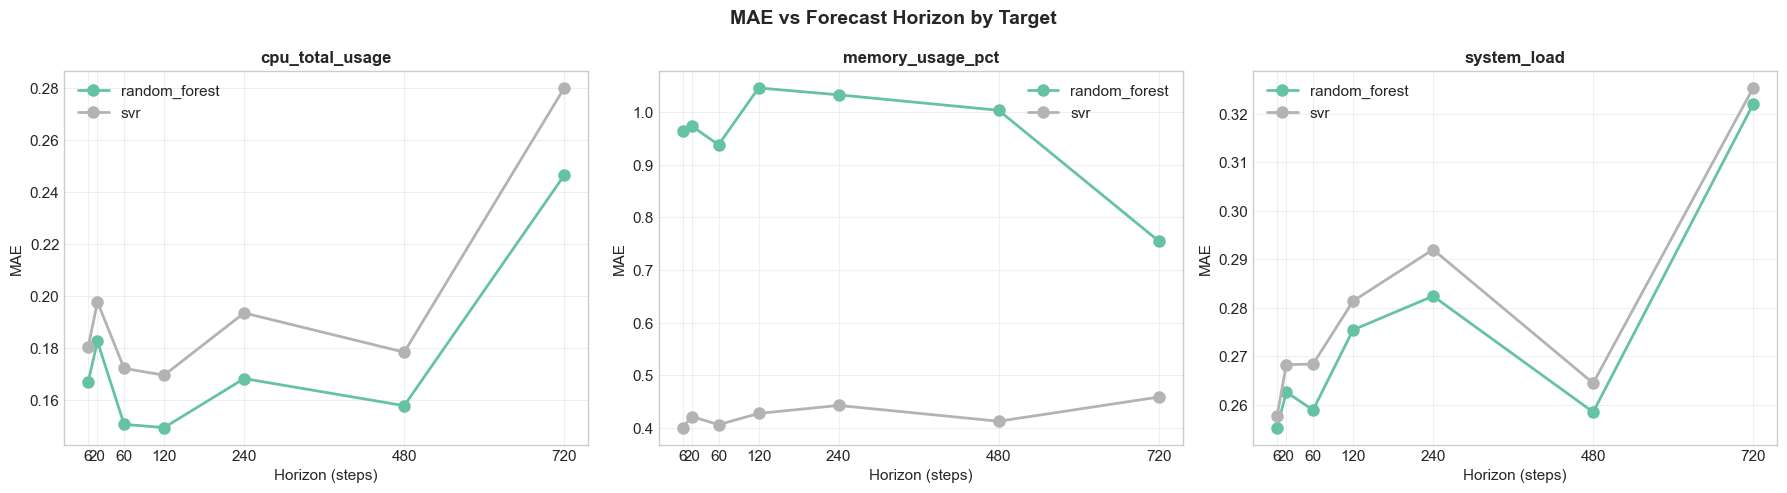

✓ Saved: horizon_mae_comparison.png


In [74]:
# MAE vs Horizon - One plot per target
if len(results_df) > 0:
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(18, 5))
    fig.suptitle('MAE vs Forecast Horizon by Target', fontsize=14, fontweight='bold')
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(MODEL_TYPES)))
    
    for idx, target in enumerate(TARGETS):
        ax = axes[idx] if len(TARGETS) > 1 else axes
        target_data = results_df[results_df['target'] == target]
        
        for i, model_type in enumerate(MODEL_TYPES):
            model_data = target_data[target_data['model'] == model_type]
            if len(model_data) > 0:
                ax.plot(
                    model_data['H'], 
                    model_data['mae'],
                    marker='o', 
                    label=model_type,
                    color=colors[i],
                    linewidth=2,
                    markersize=8
                )
        
        ax.set_title(target, fontsize=12, fontweight='bold')
        ax.set_xlabel('Horizon (steps)')
        ax.set_ylabel('MAE')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(HORIZONS)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'horizon_mae_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: horizon_mae_comparison.png")


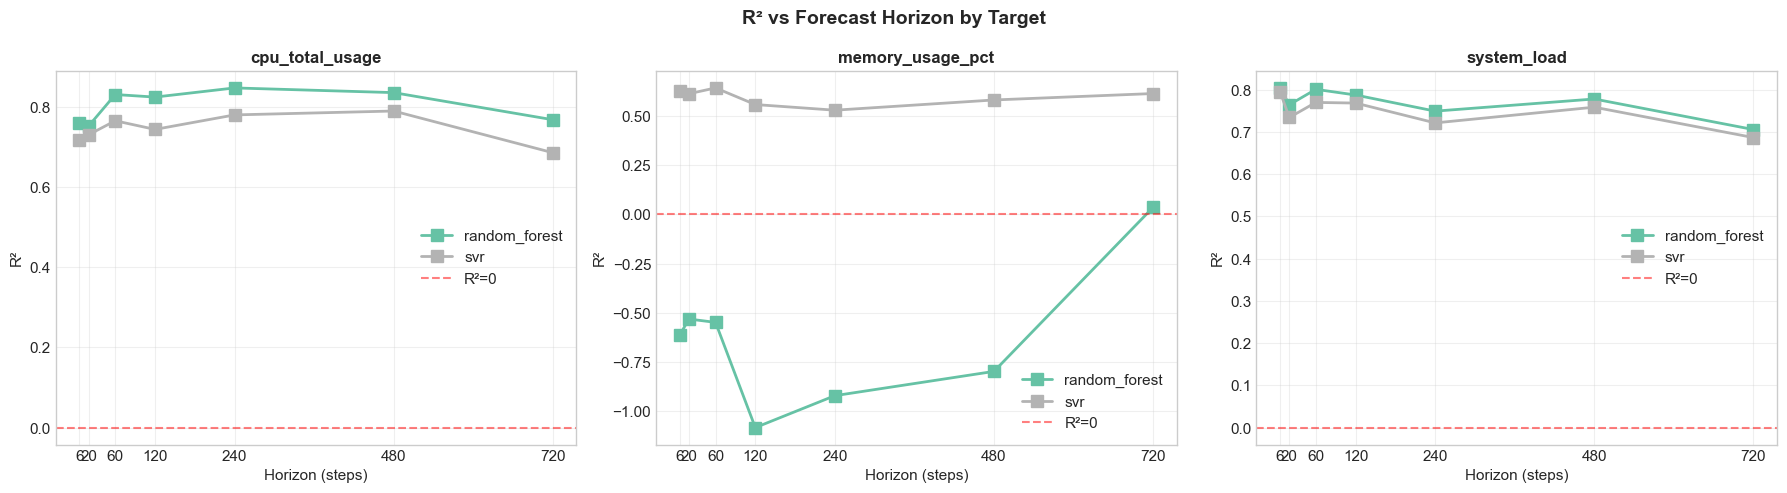

✓ Saved: horizon_r2_comparison.png


In [75]:
# R² vs Horizon
if len(results_df) > 0:
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(18, 5))
    fig.suptitle('R² vs Forecast Horizon by Target', fontsize=14, fontweight='bold')
    
    for idx, target in enumerate(TARGETS):
        ax = axes[idx] if len(TARGETS) > 1 else axes
        target_data = results_df[results_df['target'] == target]
        
        for i, model_type in enumerate(MODEL_TYPES):
            model_data = target_data[target_data['model'] == model_type]
            if len(model_data) > 0:
                ax.plot(
                    model_data['H'], 
                    model_data['r2'],
                    marker='s', 
                    label=model_type,
                    color=colors[i],
                    linewidth=2,
                    markersize=8
                )
        
        ax.set_title(target, fontsize=12, fontweight='bold')
        ax.set_xlabel('Horizon (steps)')
        ax.set_ylabel('R²')
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='R²=0')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(HORIZONS)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'horizon_r2_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: horizon_r2_comparison.png")


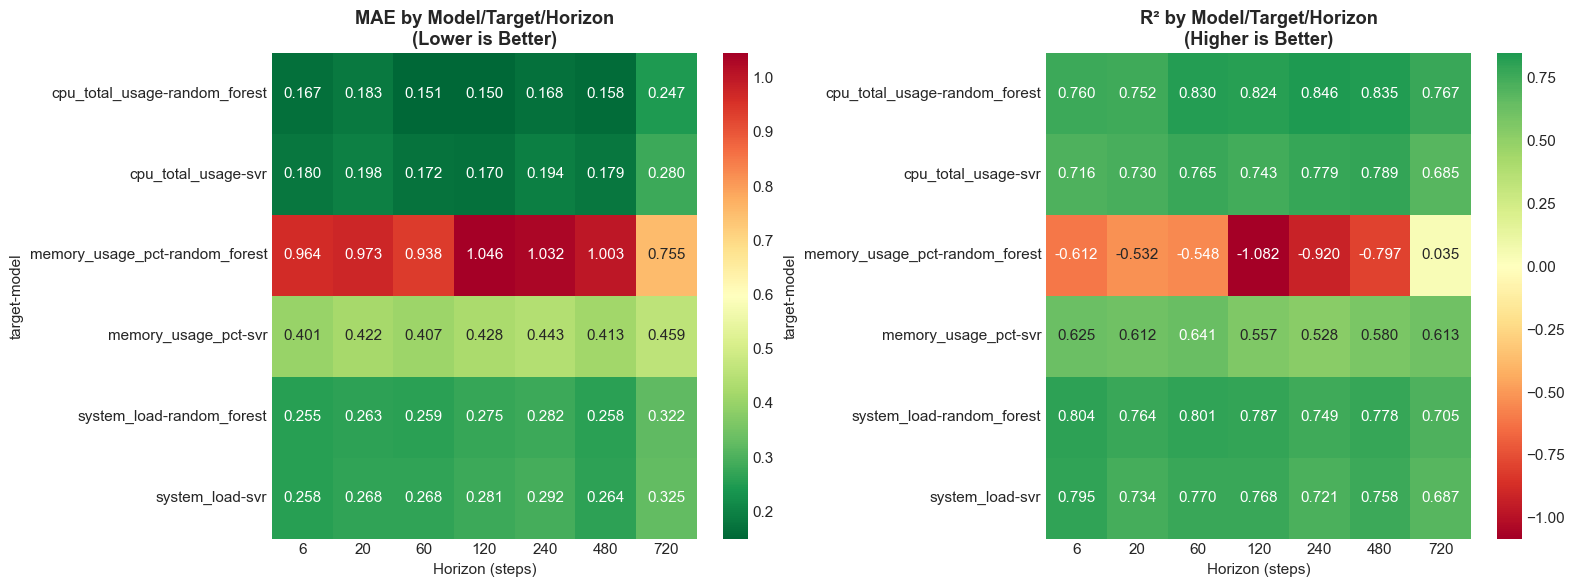

✓ Saved: horizon_heatmaps.png


In [76]:
# Heatmap: Best model for each target at each horizon
if len(results_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # MAE Heatmap (lower is better)
    pivot_mae_full = results_df.pivot_table(
        index=['target', 'model'],
        columns='H',
        values='mae'
    )
    
    sns.heatmap(
        pivot_mae_full, 
        annot=True, 
        fmt='.3f', 
        cmap='RdYlGn_r',  # Red = high (bad), Green = low (good)
        ax=axes[0]
    )
    axes[0].set_title('MAE by Model/Target/Horizon\n(Lower is Better)', fontweight='bold')
    axes[0].set_xlabel('Horizon (steps)')
    
    # R² Heatmap (higher is better)
    pivot_r2_full = results_df.pivot_table(
        index=['target', 'model'],
        columns='H',
        values='r2'
    )
    
    sns.heatmap(
        pivot_r2_full, 
        annot=True, 
        fmt='.3f', 
        cmap='RdYlGn',  # Green = high (good), Red = low (bad)
        ax=axes[1],
        center=0
    )
    axes[1].set_title('R² by Model/Target/Horizon\n(Higher is Better)', fontweight='bold')
    axes[1].set_xlabel('Horizon (steps)')
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'horizon_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: horizon_heatmaps.png")


## 10. Best Horizon Selection


In [77]:
def find_best_horizon(
    df: pd.DataFrame,
    target: str,
    model: str,
    metric: str = 'mae',
    threshold: float = None,
    r2_min: float = 0.0
) -> Optional[int]:
    """
    Tìm horizon tốt nhất cho một target/model
    
    Tiêu chí:
    1. R² >= r2_min
    2. metric (MAE) <= threshold (nếu có)
    3. Chọn H lớn nhất thỏa mãn các điều kiện trên
    """
    subset = df[(df['target'] == target) & (df['model'] == model)].copy()
    
    if len(subset) == 0:
        return None
    
    # Filter by R² threshold
    valid = subset[subset['r2'] >= r2_min]
    
    # Filter by metric threshold if specified
    if threshold is not None:
        valid = valid[valid[metric] <= threshold]
    
    if len(valid) == 0:
        return None
    
    # Return maximum valid horizon
    return valid['H'].max()


def analyze_best_horizons(df: pd.DataFrame) -> pd.DataFrame:
    """
    Phân tích và tìm horizon tốt nhất cho từng model/target
    """
    results = []
    
    for model in df['model'].unique():
        for target in df['target'].unique():
            subset = df[(df['model'] == model) & (df['target'] == target)]
            
            if len(subset) == 0:
                continue
            
            # Find best horizon with R² > 0
            best_h = find_best_horizon(df, target, model, r2_min=0.0)
            
            # Get metrics at smallest horizon (baseline)
            min_h_row = subset[subset['H'] == subset['H'].min()].iloc[0]
            
            # Get metrics at best horizon
            if best_h:
                best_h_row = subset[subset['H'] == best_h].iloc[0]
                best_mae = best_h_row['mae']
                best_r2 = best_h_row['r2']
            else:
                best_mae = None
                best_r2 = None
            
            results.append({
                'model': model,
                'target': target,
                'best_H': best_h,
                'best_H_minutes': best_h * 0.5 if best_h else None,
                'best_mae': best_mae,
                'best_r2': best_r2,
                'baseline_mae': min_h_row['mae'],
                'baseline_r2': min_h_row['r2'],
            })
    
    return pd.DataFrame(results)


if len(results_df) > 0:
    print("\n" + "="*80)
    print("BEST HORIZON ANALYSIS")
    print("Tiêu chí: H lớn nhất sao cho R² > 0")
    print("="*80)
    
    best_horizons_df = analyze_best_horizons(results_df)
    display(best_horizons_df)



BEST HORIZON ANALYSIS
Tiêu chí: H lớn nhất sao cho R² > 0


,model,target,best_H,best_H_minutes,best_mae,best_r2,baseline_mae,baseline_r2
0,random_forest,cpu_total_usage,720,360.000000,0.246598,0.767239,0.167019,0.760048
1,random_forest,memory_usage_pct,720,360.000000,0.755015,0.035107,0.963617,-0.612307
2,random_forest,system_load,720,360.000000,0.321942,0.705484,0.255281,0.803936
3,svr,cpu_total_usage,720,360.000000,0.280154,0.685106,0.180428,0.715669
4,svr,memory_usage_pct,720,360.000000,0.459075,0.612861,0.401153,0.624649
5,svr,system_load,720,360.000000,0.325280,0.686516,0.257586,0.795025


In [78]:
# Find optimal horizon for PPO
if len(results_df) > 0:
    print("\n" + "="*80)
    print("OPTIMAL HORIZON FOR PPO")
    print("="*80)
    
    # Lấy horizon tốt nhất cho từng target (qua tất cả models)
    best_by_target = {}
    
    for target in TARGETS:
        target_data = results_df[results_df['target'] == target]
        
        # Tìm model tốt nhất cho target này (dựa trên MAE tại horizon nhỏ nhất)
        min_h = target_data['H'].min()
        baseline_data = target_data[target_data['H'] == min_h]
        best_model = baseline_data.loc[baseline_data['mae'].idxmin(), 'model']
        
        # Tìm best horizon cho model đó
        best_h = find_best_horizon(results_df, target, best_model, r2_min=0.0)
        
        best_by_target[target] = {
            'best_model': best_model,
            'best_H': best_h,
            'best_H_minutes': best_h * 0.5 if best_h else None
        }
        
        print(f"\n{target}:")
        print(f"  Best model: {best_model}")
        print(f"  Best horizon: H={best_h} ({best_h*0.5 if best_h else 'N/A'}min)")
    
    # Horizon chung cho PPO
    all_best_h = [v['best_H'] for v in best_by_target.values() if v['best_H'] is not None]
    
    if all_best_h:
        H_final = min(all_best_h)
        print(f"\n{'='*60}")
        print(f"RECOMMENDED HORIZON FOR PPO: H = {H_final} ({H_final * 0.5} minutes)")
        print(f"{'='*60}")
        print(f"\nGiải thích: Chọn H = min(H_cpu*, H_mem*, H_load*) = {H_final}")
        print(f"để đảm bảo tất cả các biến dự báo đều có độ tin cậy chấp nhận được.")



OPTIMAL HORIZON FOR PPO

cpu_total_usage:
  Best model: random_forest
  Best horizon: H=720 (360.0min)

memory_usage_pct:
  Best model: svr
  Best horizon: H=720 (360.0min)

system_load:
  Best model: random_forest
  Best horizon: H=720 (360.0min)

RECOMMENDED HORIZON FOR PPO: H = 720 (360.0 minutes)

Giải thích: Chọn H = min(H_cpu*, H_mem*, H_load*) = 720
để đảm bảo tất cả các biến dự báo đều có độ tin cậy chấp nhận được.


## 11. Model Comparison Summary


In [79]:
if len(results_df) > 0:
    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)
    
    # Tìm model tốt nhất cho mỗi target tại horizon trung bình
    mid_horizon = HORIZONS[len(HORIZONS)//2]  # Lấy horizon giữa
    
    print(f"\nSo sánh tại H = {mid_horizon} ({mid_horizon * 0.5} phút):")
    print("-" * 60)
    
    for target in TARGETS:
        subset = results_df[(results_df['target'] == target) & (results_df['H'] == mid_horizon)]
        
        if len(subset) > 0:
            best_idx = subset['mae'].idxmin()
            best_row = subset.loc[best_idx]
            
            print(f"\n{target}:")
            print(f"  Best model: {best_row['model']}")
            print(f"  MAE: {best_row['mae']:.4f}")
            print(f"  R²: {best_row['r2']:.4f}")
            
            # Show all models comparison
            print(f"\n  All models:")
            for _, row in subset.sort_values('mae').iterrows():
                marker = "★" if row['model'] == best_row['model'] else " "
                print(f"  {marker} {row['model']:25s} MAE={row['mae']:.4f}, R²={row['r2']:.4f}")



MODEL COMPARISON SUMMARY

So sánh tại H = 120 (60.0 phút):
------------------------------------------------------------

cpu_total_usage:
  Best model: random_forest
  MAE: 0.1496
  R²: 0.8237

  All models:
  ★ random_forest             MAE=0.1496, R²=0.8237
    svr                       MAE=0.1697, R²=0.7431

memory_usage_pct:
  Best model: svr
  MAE: 0.4280
  R²: 0.5570

  All models:
  ★ svr                       MAE=0.4280, R²=0.5570
    random_forest             MAE=1.0455, R²=-1.0824

system_load:
  Best model: random_forest
  MAE: 0.2754
  R²: 0.7872

  All models:
  ★ random_forest             MAE=0.2754, R²=0.7872
    svr                       MAE=0.2814, R²=0.7681


## 12. Save Final Results


In [80]:
if len(results_df) > 0:
    # Save comprehensive results
    final_results = {
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'config': {
            'horizons': HORIZONS,
            'horizons_minutes': [h * 0.5 for h in HORIZONS],
            'targets': TARGETS,
            'models': MODEL_TYPES,
            'sample_rate': EVAL_SAMPLE_RATE
        },
        'summary': {
            'total_evaluations': len(records),
            'total_time_seconds': total_time
        },
        'best_by_target': best_by_target if 'best_by_target' in dir() else {},
        'recommended_horizon': H_final if 'H_final' in dir() else None,
        'all_results': records
    }
    
    # Save as JSON
    import json
    
    def convert_types(obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, dict):
            return {k: convert_types(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_types(i) for i in obj]
        return obj
    
    output_json = RESULTS_DIR / 'horizon_eval_full.json'
    with open(output_json, 'w') as f:
        json.dump(convert_types(final_results), f, indent=2)
    
    print(f"\n✓ Full results saved to: {output_json}")
    print(f"✓ CSV results saved to: {RESULTS_DIR / 'horizon_eval.csv'}")
    print(f"✓ Plots saved to: {RESULTS_DIR}")
    
    print("\n" + "="*80)
    print("EVALUATION COMPLETE!")
    print("="*80)



✓ Full results saved to: forecast_result\horizon_eval_full.json
✓ CSV results saved to: forecast_result\horizon_eval.csv
✓ Plots saved to: forecast_result

EVALUATION COMPLETE!


---

## Tóm tắt

Notebook này đã:
1. Load dữ liệu train/test cho 3 targets
2. Đánh giá 4 loại model (SVR, Random Forest, ARIMAX, Hybrid Prophet+LSTM)
3. Test với 6 horizons khác nhau (3-18 phút)
4. Tính toán metrics (MAE, RMSE, R²) cho mỗi combination
5. Visualize kết quả và tìm horizon tốt nhất

### Các file output:
- `forecast_result/horizon_eval.csv`: Bảng kết quả chi tiết
- `forecast_result/horizon_eval_full.json`: Kết quả đầy đủ dạng JSON
- `forecast_result/horizon_*.png`: Biểu đồ so sánh

### Cách sử dụng:
1. Chạy toàn bộ notebook
2. Điều chỉnh `EVAL_SAMPLE_RATE` để chạy nhanh hơn (thử nghiệm) hoặc đầy đủ (evaluation cuối)
3. Xem kết quả tại section 10-11 để chọn horizon phù hợp cho PPO

### Thêm model khác:
Nếu muốn đánh giá thêm ARIMAX hoặc Hybrid Prophet+LSTM, thêm vào `MODEL_TYPES`:
```python
MODEL_TYPES = ['svr', 'random_forest', 'arimax', 'hybrid_prophet_lstm']
```
